# Geo Classifier 🏞️

## Problem 🤔

Classify images of natural scenes into 6 categories: Buildings, Forests, Glaciers, Mountains, Seas, or Streets.

## Data 📊

[Intel Image Classification Dataset from Kaggle](https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data)

## Target 🎯

This is a fun project... So, for the first version let's try to achieve an accuracy of 65%!

## Features ✨

**id** -> image id of the geographic location

**geo_cat** -> category of the geographic scene out of the 6: buildings, forests, glaciers, moutains, seas or streets

## Workspace Setup 🛠️

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os
import kagglehub

In [2]:
# drive.mount('/content/drive')

In [3]:
os.environ["KAGGLEHUB_CACHE"] = "/content/drive/MyDrive/kaggle_datasets"

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

100%|██████████| 346M/346M [00:03<00:00, 116MB/s]

Extracting files...


Path to dataset files: /content/drive/MyDrive/kaggle_datasets/datasets/puneet6060/intel-image-classification/versions/2


In [4]:
# @title Global Variabels
BATCH_SIZE = 32
IMAGE_SIZE = (150, 150)

In [5]:
# train datase
train_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_train/seg_train", labels="inferred", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical")

# test and validation datasets
test_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_test/seg_test", labels="inferred", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical", validation_split=0.2, subset="training", seed=42)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_test/seg_test", labels="inferred", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical", validation_split=0.2, subset="validation", seed=42)

# pred dataset
preds_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_pred/seg_pred", labels=None, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical")

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Using 2400 files for training.
Found 3000 files belonging to 6 classes.
Using 600 files for validation.
Found 7301 files.


In [6]:
train_ds.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.float32, name=None))>

In [7]:
train_ds.element_spec

(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 6), dtype=tf.float32, name=None))

## EDA 🔎

In [8]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [9]:
# from collections import Counter

# counts = Counter([])
# for _, labels in train_ds:
#     for label in labels:
#         counts.update(np.where(label.numpy() == 1)[0].tolist())

# class_distributions = {class_names[i]: value for i, value in dict(counts).items()}
# print("Class distribution:", class_distributions)

class_distributions = {'buildings': 2191, 'glacier': 2404, 'forest': 2271, 'street': 2382, 'mountain': 2512, 'sea': 2274}

print(f"Class distribution: {class_distributions}")

Class distribution: {'buildings': 2191, 'glacier': 2404, 'forest': 2271, 'street': 2382, 'mountain': 2512, 'sea': 2274}


In [10]:
class_distribution_df = pd.DataFrame(list(class_distributions.items()), columns=['Class', 'Count'])
class_distribution_df

,Class,Count
0,buildings,2191
1,glacier,2404
2,forest,2271
3,street,2382
4,mountain,2512
5,sea,2274


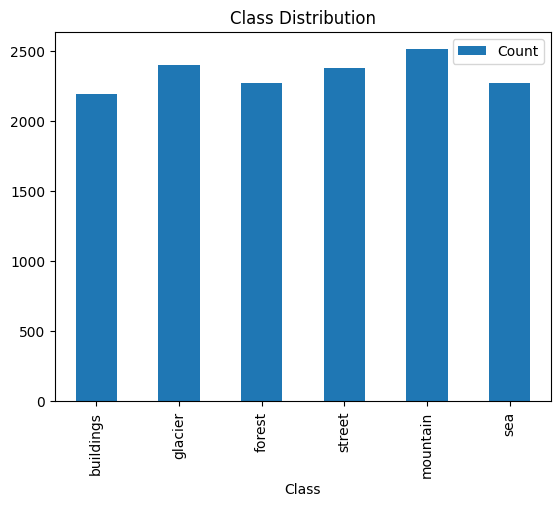

In [11]:
class_distribution_df.plot(kind='bar', x='Class', y='Count', title='Class Distribution')
plt.show()

In [12]:
# plt.figure(figsize=(14, 24))
# for images, labels in train_ds.take(1):  # take one batch
#     for i in range(BATCH_SIZE):  # show first 9 images
#         plt.subplot(8, 4, i + 1)

#         plt.grid(False)
#         plt.xticks([])
#         plt.yticks([])
#         plt.axis("off")

#         plt.imshow(images[i].numpy().astype("uint8"))
#         plt.title(class_names[np.where(labels[i] == 1)[0][0]])
#     break

# plt.tight_layout()
# plt.subplots_adjust(hspace=0.3)
# plt.show()

In [13]:
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Image shape: (32, 150, 150, 3)
Label shape: (32, 6)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>


## Data Preprocessing ⚙️

In [14]:
augmentation_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),  # rescale pixel values to [0,1]
    tf.keras.layers.RandomRotation(factor=0.15),  # randomly rotate images (factor is a fraction of pi radians)
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),  # randomly zoom images
    tf.keras.layers.Rescaling(1./255),  # rescale pixel values after augmentation
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # flips the image
    tf.keras.layers.RandomTranslation(0.1, 0.1) # for shifting the image (+/- 10% width and +/- 10% height)
])

augmented_train_ds = train_ds.map(lambda x, y: (augmentation_model(x, training=True), y))

## Modelling 💡

In [108]:
INPUT_SHAPE = [150, 150, 3]
OUTPUT_SHAPE = len(class_distributions.keys())
N_EPOCHS = 128

In [125]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout, BatchNormalization

def build_and_compile_vanilla_cnn():
    model = Sequential()

    model.add(tf.keras.layers.Input(INPUT_SHAPE))

    model.add(Conv2D(32, (3, 3), activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(64, activation="relu"))

    model.add(Dense(OUTPUT_SHAPE, activation="softmax"))

    model.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])

    return model

In [126]:
checkpoint_filepath = "/content/drive/MyDrive/google_colab_model_checkpoints/geo_classifier/vanilla_cnn_v1.weights.h5"

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

In [127]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)

In [128]:
vanilla_cnn_model = build_and_compile_vanilla_cnn()

history = vanilla_cnn_model.fit(
    augmented_train_ds.take(100),
    epochs=N_EPOCHS,
    validation_data=val_ds.take(100),
    callbacks=[early_stopping, model_checkpoint_callback]
)

Epoch 1/128
100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 267ms/step - accuracy: 0.3901 - loss: 1.5161 - val_accuracy: 0.2150 - val_loss: 9289.9502
Epoch 2/128
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 260ms/step - accuracy: 0.5027 - loss: 1.2727 - val_accuracy: 0.2833 - val_loss: 10621.8887
Epoch 3/128
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - accuracy: 0.5131 - loss: 1.2479 - val_accuracy: 0.3217 - val_loss: 18305.2852
Epoch 4/128
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 262ms/step - accuracy: 0.5452 - loss: 1.1931 - val_accuracy: 0.3083 - val_loss: 41088.7422
Epoch 5/128
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 251ms/step - accuracy: 0.5455 - loss: 1.1755 - val_accuracy: 0.3017 - val_loss: 65617.8047
Epoch 6/128
100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 252ms/step - accuracy: 0.5654 - loss: 1.1416 - val_accuracy: 0.3167 - val_loss: 120989.4922


## Evaluation ✅